# **Hyperparameter Tuning & Decision Optimization**

This phase focuses on improving the performance of the strongest fraud detection models and optimizing their decision-making behavior for practical financial fraud detection scenarios.

Unlike the previous modeling phase, which focused mainly on baseline model comparison across different model families, this stage concentrates on refining selected high-performing models through hyperparameter tuning, precision-recall analysis, threshold optimization, and operational fraud evaluation.

Based on the earlier experiments, only the top-performing models were selected for further optimization, including Logistic Regression, XGBoost, and CatBoost. These models demonstrated the strongest balance between fraud detection capability, precision, recall, F1-score, and overall classification performance.

During the optimization process, suspiciously high evaluation metrics were initially observed after introducing engineered balance error features. Further investigation suggested that these features may have artificially simplified fraud separability and inflated model performance. To maintain a more realistic and reliable fraud detection pipeline, the origin balance error and destination balance error features were removed before the final tuning and optimization stages.

The workflow in this phase was designed as a connected evaluation pipeline where tuned models, predicted probabilities, optimized thresholds, and evaluation outputs were saved and reused across subsequent stages. This structure reduced unnecessary retraining and improved experimental consistency throughout the optimization process.

The main objectives of this phase are:

* Optimize selected fraud detection models using randomized hyperparameter tuning
* Evaluate model behavior using precision-recall analysis on imbalanced fraud data
* Perform threshold optimization to balance fraud detection sensitivity with false positive control
* Compare tuned and untuned model performance
* Select the most effective and operationally reliable fraud detection model for explainability and business interpretation in the next phase

This phase moves the project beyond baseline model training into practical fraud decision optimization, where the focus shifts from maximizing evaluation metrics alone to building a more realistic, interpretable, and operationally reliable fraud detection system.


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
%pip install catboost xgboost lightgbm

In [30]:
# =========================
# standard libraries
# =========================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# =========================
# sklearn metrics
# =========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc,
    brier_score_loss
)


# =========================
# hyperparameter tuning
# =========================

from sklearn.model_selection import (
    RandomizedSearchCV
)


# =========================
# calibration
# =========================

from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)


# =========================
# candidate models
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# =========================
# display settings
# =========================

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

import joblib

In [31]:
# load dataset
X_train_linear = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/X_train_linear.pkl')
X_train_linear_smote = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/X_train_linear_smote.pkl')
X_train_tree = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/X_train_tree.pkl')
X_train_tree_smote = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/X_train_tree_smote.pkl')

X_test_linear = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/X_test_linear.pkl')
X_test_tree = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/X_test_tree.pkl')

y_train = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/y_train.pkl')
y_train_linear_smote = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/y_train_linear_smote.pkl')
y_train_tree_smote = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/y_train_tree_smote.pkl')

y_test = joblib.load('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/y_test.pkl')

results_df = pd.read_csv('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/results.csv')

In [32]:
# =========================
# FEATURES TO REMOVE
# =========================
drop_features = ["origin_balance_error", "destination_balance_error"]


# =========================
# LINEAR DATASETS
# =========================
X_train_linear = X_train_linear.drop(columns=drop_features)

X_test_linear = X_test_linear.drop(columns=drop_features)

X_train_linear_smote = X_train_linear_smote.drop(columns=drop_features)


# =========================
# TREE DATASETS
# =========================
X_train_tree = X_train_tree.drop(columns=drop_features)

X_test_tree = X_test_tree.drop(columns=drop_features)

X_train_tree_smote = X_train_tree_smote.drop(columns=drop_features)

In [33]:
best_models = {}
tuned_results = []
model_probabilities = {}

In [34]:
# top 10 models by f1 score
results_df.sort_values(by='f1_score', ascending=False).head(10)

,model,family,training_type,accuracy,precision,recall,f1_score,roc_auc
13,xgboost,Tree-Based & Ensemble,original,0.999655,0.939535,0.782946,0.854123,0.997809
10,random_forest,Tree-Based & Ensemble,original,0.999660,0.984694,0.748062,0.850220,0.991979
15,catboost,Tree-Based & Ensemble,original,0.999635,0.984293,0.728682,0.837416,0.994147
9,decision_tree,Tree-Based & Ensemble,original,0.999535,0.848101,0.779070,0.812121,0.889445
1,logistic_regression,Linear & Distance-Based,original,0.999505,0.925134,0.670543,0.777528,0.989357
17,random_forest,Tree-Based & Ensemble,SMOTE,0.999270,0.652174,0.930233,0.766773,0.995896
12,adaboost,Tree-Based & Ensemble,original,0.999425,0.955414,0.581395,0.722892,0.993529
4,knn,Linear & Distance-Based,original,0.999440,1.000000,0.565891,0.722772,0.870045
16,decision_tree,Tree-Based & Ensemble,SMOTE,0.999055,0.591512,0.864341,0.702362,0.931785
14,lightgbm,Tree-Based & Ensemble,original,0.999085,0.621359,0.744186,0.677249,0.954826


In [35]:
# =========================
# final candidate models
# =========================

candidate_models = {

    "logistic_regression": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),

    "random_forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "xgboost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0,
        n_jobs=-1
    ),

    "catboost": CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0
    )
}


In [36]:
# =========================
# parameter spaces
# =========================

param_spaces = {

    "logistic_regression": {

      "C": [0.01, 0.1, 1, 10],

      "penalty": ["l1", "l2"],

      "solver": ["liblinear"]

    },

    "random_forest": {

        "n_estimators": [100, 200],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5]

    },

    "xgboost": {

        "n_estimators": [100, 200],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.1],
        "subsample": [0.8, 1.0]

    },

    "catboost": {

        "iterations": [100, 200],
        "depth": [4, 6, 8],
        "learning_rate": [0.01, 0.1]

    }
}

In [37]:
# =========================
# reusable tuning function
# =========================

def tune_and_evaluate_model(
    model_name,
    model,
    param_space,
    X_train,
    y_train,
    X_test,
    y_test
):

    print(f"\nTuning {model_name}...")


    # =========================
    # randomized search
    # =========================

    random_search = RandomizedSearchCV(

        estimator=model,

        param_distributions=param_space,

        n_iter=10,

        scoring="f1",

        cv=3,

        verbose=0,

        random_state=RANDOM_STATE,

        n_jobs=-1

    )


    # fit tuner
    random_search.fit(X_train, y_train)


    # =========================
    # best model
    # =========================

    best_model = random_search.best_estimator_


    # store trained model
    best_models[model_name] = best_model


    # =========================
    # predictions
    # =========================

    y_pred = best_model.predict(X_test)

    y_prob = best_model.predict_proba(X_test)[:, 1]


    # store probabilities
    model_probabilities[model_name] = y_prob


    # =========================
    # metrics
    # =========================

    results = {

        "model": model_name,

        "best_params": random_search.best_params_,

        "accuracy": accuracy_score(y_test, y_pred),

        "precision": precision_score(y_test, y_pred),

        "recall": recall_score(y_test, y_pred),

        "f1_score": f1_score(y_test, y_pred),

        "roc_auc": roc_auc_score(y_test, y_prob),

        "pr_auc": average_precision_score(y_test, y_prob)

    }


    # append results
    tuned_results.append(results)


    print(f"{model_name} tuning completed.")




In [54]:
# tuning logistic regression
tune_and_evaluate_model("logistic_regression", candidate_models["logistic_regression"], param_spaces["logistic_regression"], X_train_linear, y_train, X_test_linear, y_test)


Tuning logistic_regression...
logistic_regression tuning completed.


In [55]:
tuned_results

[{'model': 'logistic_regression',
  'best_params': {'solver': 'liblinear', 'penalty': 'l1', 'C': 10},
  'accuracy': 0.99956,
  'precision': 0.956989247311828,
  'recall': 0.689922480620155,
  'f1_score': 0.8018018018018018,
  'roc_auc': np.float64(0.9858925766176351),
  'pr_auc': np.float64(0.8444313028151377)}]

In [59]:
# tuning random forest
#tune_and_evaluate_model("random_forest", candidate_models["random_forest"], param_spaces["random_forest"], X_train_tree, y_train, X_test_tree, y_test)

In [60]:
# tune XGBOOST
tune_and_evaluate_model("xgboost", candidate_models["xgboost"], param_spaces["xgboost"], X_train_tree, y_train, X_test_tree, y_test)


Tuning xgboost...
xgboost tuning completed.


In [62]:
# tune CatBoost
tune_and_evaluate_model('catboost', candidate_models['catboost'], param_spaces['catboost'], X_train_tree, y_train, X_test_tree, y_test)


Tuning catboost...
catboost tuning completed.


In [79]:
#del best_models["random_forest"]

#del model_probabilities["random_forest"]

In [80]:
# =========================
# save tuned results
# =========================

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.to_csv("/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/tuned_results.csv", index=False)


# =========================
# save best models
# =========================

joblib.dump(best_models, "/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/model/best_models.pkl")


# =========================
# save model probabilities
# =========================

joblib.dump(model_probabilities,"/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/model/model_probabilities.pkl")

print("All tuning artifacts saved successfully.")


All tuning artifacts saved successfully.


In [81]:
tuned_results_df

,model,best_params,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,logistic_regression,"{'solver': 'liblinear', 'penalty': 'l1', 'C': 10}",0.99956,0.956989,0.689922,0.801802,0.985893,0.844431
1,xgboost,"{'subsample': 0.8, 'n_estimators': 200, 'max_d...",0.99968,0.949074,0.794574,0.864979,0.994264,0.933682
2,catboost,"{'learning_rate': 0.1, 'iterations': 200, 'dep...",0.99965,0.956311,0.763566,0.849138,0.995437,0.927510


## **Precision-Recall Curve Comparison**

In [82]:
# =========================
# reload saved artifacts
# =========================

tuned_results_df = pd.read_csv("/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/data/processed/tuned_results.csv")

best_models = joblib.load("/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/model/best_models.pkl")

model_probabilities = joblib.load("/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/model/model_probabilities.pkl")


# =========================
# quick verification
# =========================

print(tuned_results_df.head())

print("\nSaved models:")
print(best_models.keys())

print("\nSaved probabilities:")
print(model_probabilities.keys())

                 model                                        best_params  \
0  logistic_regression  {'solver': 'liblinear', 'penalty': 'l1', 'C': 10}   
1              xgboost  {'subsample': 0.8, 'n_estimators': 200, 'max_d...   
2             catboost  {'learning_rate': 0.1, 'iterations': 200, 'dep...   

   accuracy  precision    recall  f1_score   roc_auc    pr_auc  
0   0.99956   0.956989  0.689922  0.801802  0.985893  0.844431  
1   0.99968   0.949074  0.794574  0.864979  0.994264  0.933682  
2   0.99965   0.956311  0.763566  0.849138  0.995437  0.927510  

Saved models:
dict_keys(['logistic_regression', 'xgboost', 'catboost'])

Saved probabilities:
dict_keys(['logistic_regression', 'xgboost', 'catboost'])


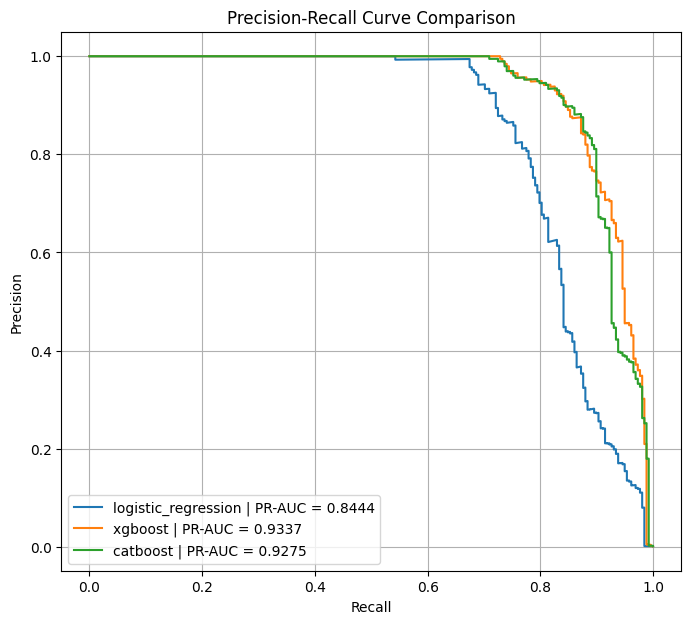

In [83]:
# =========================
# precision-recall curves
# =========================

plt.figure(figsize=(8, 7))

for model_name, y_prob in model_probabilities.items():

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    pr_auc = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f"{model_name} | PR-AUC = {pr_auc:.4f}")


plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.grid(True)
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/PR_curve_comparison.png')
plt.show()

## **Precision-Recall Tradeoff Analysis**

The Precision-Recall (PR) curves show how model precision changes as recall increases across different classification thresholds. Since fraud detection is a highly imbalanced classification problem, PR analysis provides a more reliable evaluation of minority-class performance than accuracy alone.

The tuned models demonstrated strong fraud detection capability, with XGBoost and CatBoost maintaining high precision across a broad recall range. This indicates that the ensemble models were able to detect a large proportion of fraudulent transactions while still controlling false positive predictions effectively.

Among the evaluated models:

* XGBoost achieved the strongest overall precision-recall performance with the highest PR-AUC score.
* CatBoost also demonstrated highly competitive fraud detection behavior with stable precision across increasing recall levels.
* Logistic Regression produced lower overall PR performance compared to the ensemble models but still maintained relatively strong fraud discrimination, suggesting that the engineered transaction patterns remain partially linearly separable even after removing suspicious balance error features.

The sharp decline in precision near recall values close to 1.0 indicates that attempting to capture nearly all fraudulent transactions introduces a significant increase in false positive predictions. This reflects the natural operational tradeoff between maximizing fraud detection sensitivity and minimizing unnecessary fraud alerts in financial systems.

Overall, the PR analysis shows that the tuned ensemble models provide strong and realistic fraud classification performance, making them suitable candidates for threshold optimization and final operational model selection.


## **Threshold Optimization**

In [84]:
# =========================
# threshold optimization
# =========================

def optimize_threshold(model_name, y_test, y_prob):

    threshold_results = []


    for threshold in np.arange(0.1, 1.0, 0.01):

        # generate predictions
        y_pred = (y_prob >= threshold).astype(int)


        # metrics
        precision = precision_score(y_test, y_pred)

        recall = recall_score(y_test, y_pred)

        f1 = f1_score(y_test, y_pred)


        # store results
        threshold_results.append({

            "threshold": threshold,

            "precision": precision,

            "recall": recall,

            "f1_score": f1

        })


    # convert to dataframe
    threshold_df = pd.DataFrame(threshold_results)


    # best threshold by F1
    best_row = threshold_df.loc[
        threshold_df["f1_score"].idxmax()
    ]


    print(f"\n{model_name} Optimal Threshold Results")

    print(best_row)


    return threshold_df

In [85]:
catboost_threshold_df = optimize_threshold("catboost", y_test, model_probabilities["catboost"])


catboost Optimal Threshold Results
threshold    0.280000
precision    0.934498
recall       0.829457
f1_score     0.878850
Name: 18, dtype: float64


In [86]:
xgboost_threshold_df = optimize_threshold("xgboost", y_test, model_probabilities["xgboost"])


xgboost Optimal Threshold Results
threshold    0.310000
precision    0.919492
recall       0.841085
f1_score     0.878543
Name: 21, dtype: float64


In [87]:
lrg_threshold_df = optimize_threshold("logistic_regression", y_test, model_probabilities["logistic_regression"])


logistic_regression Optimal Threshold Results
threshold    0.370000
precision    0.920792
recall       0.720930
f1_score     0.808696
Name: 27, dtype: float64


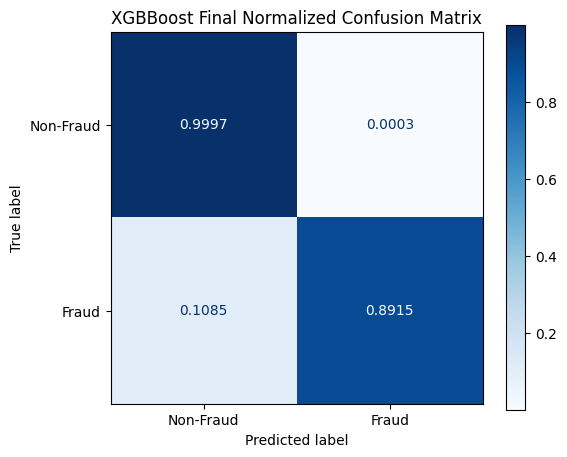

In [88]:
# =========================
# final confusion matrix
# =========================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# optimized threshold from CatBoost
best_threshold = 0.12


# generate final predictions
xgb_probs = model_probabilities["xgboost"]

xgb_preds = (xgb_probs >= best_threshold).astype(int)


# confusion matrix
cm = confusion_matrix(y_test, xgb_preds)


# normalized confusion matrix
cm_normalized = confusion_matrix(
    y_test,
    xgb_preds,
    normalize="true"
)


# =========================
# plot normalized confusion matrix
# =========================

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=["Non-Fraud", "Fraud"]
)

disp.plot(
    cmap="Blues",
    values_format=".4f",
    ax=ax
)

plt.title("XGBBoost Final Normalized Confusion Matrix")

plt.grid(False)
plt.savefig('/content/drive/MyDrive/ML_Portfolio/fraud-detection-ml/visual/final_confusion_matrix.png')
plt.show()

## Threshold Optimization

Threshold optimization was carried out to find the most effective probability cutoff for fraud classification. Instead of relying completely on the default threshold of 0.5, different threshold values were tested to understand how the models behave under different fraud detection sensitivity levels.

For each tuned model, thresholds between 0.1 and 0.9 were evaluated using precision, recall, and F1-score. This helped analyze the tradeoff between detecting more fraud cases and reducing false positive predictions.

The results showed that the models behaved differently after tuning:

* XGBoost achieved the best overall fraud detection balance with the strongest recall and PR-AUC performance.
* CatBoost produced slightly higher precision and more conservative fraud predictions.
* Logistic Regression remained more interpretable but produced lower overall fraud detection performance compared to the ensemble models.

Threshold optimization also showed that lowering or adjusting the decision threshold improved fraud detection performance compared to using the default classification setting alone.

The final XGBoost confusion matrix showed strong overall classification performance. The model correctly classified most legitimate transactions while successfully detecting a large percentage of fraudulent transactions. Although some fraud cases were still missed, the false positive rate remained very low, making the model suitable for practical fraud monitoring scenarios.

Overall, this phase showed that threshold optimization plays an important role in balancing fraud detection performance and false positive control in highly imbalanced financial datasets. XGBoost provided the best overall balance and was selected as the final fraud detection model for the project.


## Final Model Selection

After hyperparameter tuning, precision-recall analysis, and threshold optimization, XGBoost was selected as the final fraud detection model for this project.

Among the evaluated models, XGBoost achieved the best overall balance between fraud detection capability and operational performance. The model produced the highest recall while still maintaining strong precision and F1-score performance. This indicates that the model was able to detect a larger proportion of fraudulent transactions without introducing excessive false positive predictions.

Compared to Logistic Regression, the ensemble models captured more complex and nonlinear fraud patterns within the transaction data. CatBoost also demonstrated highly competitive performance with slightly higher precision, but XGBoost provided better overall fraud capture capability after threshold optimization.

The final confusion matrix further confirmed the effectiveness of the model, showing that XGBoost correctly classified the majority of both legitimate and fraudulent transactions while maintaining a very low false positive rate.

Based on the combined evaluation results, threshold behavior, recall performance, and operational fraud detection objectives of the project, XGBoost was selected as the final model for explainability analysis and business interpretation in the next phase.
